# **Cognifyz Technologies**

## **Notebook Workflow**

- 1.1 Import required libraries
- 1.2 Dataset Loading
- 1.3 Cleaning data using Pandas
- 1.4 Domain Analysis
- 1.5 Basic Checks
    - 1.5.1 Data Exploration and Preprocessing
- 1.6 Perform Tasks
- 

## 1.1 Import required libraries

In [271]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error , root_mean_squared_error , mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

## 1.2 Dataset Loading

In [274]:
df = pd.read_csv("Datasetog.csv")
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


## 1.3 Cleaning data using Pandas

In [277]:
# Drop "�" symbol from entire dataset.
df = df.applymap(lambda x: x.replace("�", "") if isinstance(x, str) else x)

In [279]:
# Drop "۱" symbol from entire dataset.
df = df.applymap(lambda x: x.replace("۱", "") if isinstance(x, str) else x)

In [281]:
# Replace "Istanbul" inplace of "stanbul" from entire dataset.
df = df.applymap(lambda x: x.replace("stanbul", "Istanbul") if isinstance(x, str) else x)

In [283]:
# Replace "Brasilia" inplace of "Bras_lia" from entire dataset.
df = df.applymap(lambda x: x.replace("Bras_lia", "Brasilia") if isinstance(x, str) else x)

In [285]:
pd.set_option("display.max_columns",None)
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml Gurme,208,Istanbul,"Kemanke Karamustafa Paa Mahallesi, Rhtm Caddes...",Karak_y,"Karak_y, Istanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz Aac,208,Istanbul,"Kouyolu Mahallesi, Muhittin st_nda Caddesi, No...",Kouyolu,"Kouyolu, Istanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 5...",Kuru_eme,"Kuru_eme, Istanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Ak Kahve,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 6...",Kuru_eme,"Kuru_eme, Istanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


## 1.4 Domain Analysis

1. **Restaurant ID** :  
   - datatype : int64  
   - It is a unique identifier for each restaurant in the dataset.  
2. **Restaurant Name** :  
   - datatype : object  
   - It is the name of the restaurant.  
3. **Country Code** :  
   - datatype : int64  
   - It is a numerical code representing the country in which the restaurant is located.  
4. **City** :  
   - datatype : object  
   - It is the name of the city where the restaurant operates.  
5. **Address** :  
   - datatype : object  
   - It is the complete address of the restaurant including street and area details.  
6. **Locality** :  
   - datatype : object  
   - It is the specific area where the restaurant is located.  
7. **Locality Verbose** :  
   - datatype : object  
   - It is the detailed version of locality information.  
8. **Longitude** :  
   - datatype : float64  
   - It is the geographical longitude coordinate of the restaurant's location.  
9. **Latitude** :  
   - datatype : float64  
   - It is the geographical latitude coordinate of the restaurant's location.  
10. **Cuisines** :  
    - datatype : object  
    - It is  types of cuisines served at the restaurant (e.g., “Italian, Chinese, Indian”).  
11. **Average Cost for two** :  
    - datatype : int64  
    - It is the average cost of a meal for two people in the local currency.  
12. **Currency** :  
    - datatype : object  
    - It is the currency in which the restaurant’s prices are listed (e.g., INR, Dollar, Pula).  
13. **Has Table booking** :  
    - datatype : object  
    - It shows whether the restaurant provides an option for table booking ('Yes' or 'No').  
14. **Has Online delivery** :  
    - datatype : object  
    - It shows whether the restaurant offers online delivery services ('Yes' or 'No').  
15. **Is delivering now** :  
    - datatype : object  
    - It shows whether the restaurant is currently accepting online orders ('Yes' or 'No').  
16. **Switch to order menu** :  
    - datatype : object  
    - It shows if users can directly switch to the restaurant’s online order menu (Yes or No).  
17. **Price range** :  
    - datatype : int64  
    - It is a numerical category (usually 1–4) representing the price level of the restaurant, In which higher values indicate  higher cost.  
18. **Aggregate rating** :  
    - datatype : float64  
    - It is the average customer rating of the restaurant,ranging from 0.0 to 5.0.  
19. **Rating color** :  
    - datatype : object  
    - It is the color code corresponding to the rating level.  
20. **Rating text** :  
    - datatype : object  
    - It is the textual representation of the restaurant’s rating.  
21. **Votes** :  
    - datatype : int64  
    - It is the number of customer votes  that contributed to the restaurant’s rating.

## 1.5 Basic Checks

### 1.5.1 Data Exploration and Preprocessing

### Data Explortion

In [292]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [294]:
df.shape

(9551, 21)

- **There are 9551 rows and 21 features in this dataset.**

In [297]:
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Memory Usage: 7.96 MB


In [299]:
df.sample(7)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
5927,18144480,Zooby's Kitchen,1,New Delhi,"New Friends Colony, New Delhi",New Friends Colony,"New Friends Colony, New Delhi",77.271844,28.565280,"North Indian, Mughlai, Chinese",800,Indian Rupees(Rs.),No,No,No,No,2,2.8,Orange,Average,21
9512,5800710,The Manhattan Fish Market,191,Colombo,"31, Deal Place, Off R.A. De Mel Mawatha, Kollu...","Kollupitiya, Colombo 03","Kollupitiya, Colombo 03, Colombo",79.853364,6.906814,"Seafood, Italian",4500,Sri Lankan Rupee(LKR),No,No,No,No,4,4.0,Green,Very Good,196
3815,18383432,HoG - House of Goodies,1,New Delhi,"A 130, Neeti Bagh, Green Park, New Delhi",Green Park,"Green Park, New Delhi",77.216938,28.561084,"Bakery, Desserts",350,Indian Rupees(Rs.),No,No,No,No,1,0.0,White,Not rated,3
1320,18464003,Eggzellent,1,Gurgaon,"Plot H-16/6, DLF Phase 1, Gurgaon",DLF Phase 1,"DLF Phase 1, Gurgaon",77.100318,28.477732,Fast Food,250,Indian Rupees(Rs.),No,Yes,No,No,1,0.0,White,Not rated,1
9357,7600803,Loudons Cafe & Bakery,215,Edinburgh,"94b Fountainbridge, Fountainbridge, Edinburgh ...",Fountainbridge,"Fountainbridge, Edinburgh",-3.208363,55.943501,"Cafe, Bakery",30,Pounds(),No,No,No,No,3,3.9,Yellow,Good,63
6149,18466825,Chennai Dosa Express,1,New Delhi,"E-167/3, Samaspur Road, Pandav Nagar, New Delhi",Pandav Nagar,"Pandav Nagar, New Delhi",77.212529,28.627898,South Indian,300,Indian Rupees(Rs.),No,No,No,No,1,0.0,White,Not rated,1
2106,3538,Giani,1,Gurgaon,"A-130, Supermart 1, DLF Phase 4, Gurgaon","Supermart 1, DLF Phase 4","Supermart 1, DLF Phase 4, Gurgaon",77.086952,28.462462,"Ice Cream, Desserts",400,Indian Rupees(Rs.),No,Yes,No,No,1,3.6,Yellow,Good,115


In [301]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml Gurme,208,Istanbul,"Kemanke Karamustafa Paa Mahallesi, Rhtm Caddes...",Karak_y,"Karak_y, Istanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz Aac,208,Istanbul,"Kouyolu Mahallesi, Muhittin st_nda Caddesi, No...",Kouyolu,"Kouyolu, Istanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 5...",Kuru_eme,"Kuru_eme, Istanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Ak Kahve,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 6...",Kuru_eme,"Kuru_eme, Istanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,Istanbul,"Cafeaa Mahallesi, Bademalt Sokak, No 21/B, Kad...",Moda,"Moda, Istanbul",29.026016,40.984776,Cafe,55,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

- **There are 8 Numeric and 13 Caregorical features in our dataset.**

In [306]:
df.describe(include=['int64','float64'])

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [308]:
df.describe(include=['object'])

,Restaurant Name,City,Address,Locality,Locality Verbose,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Rating color,Rating text
count,9551,9551,9551,9551,9551,9542,9551,9551,9551,9551,9551,9551,9551
unique,7446,141,8918,1208,1265,1825,12,2,2,2,1,6,6
top,Cafe Coffee Day,New Delhi,"Dilli Haat, INA, New Delhi",Connaught Place,"Connaught Place, New Delhi",North Indian,Indian Rupees(Rs.),No,No,No,No,Orange,Average
freq,83,5473,11,122,122,936,8652,8393,7100,9517,9551,3737,3737


### Data Preprocessing

#### Null Values Imputation

In [312]:
df.isnull().sum().sort_values(ascending = False)

Cuisines                9
Restaurant ID           0
Currency                0
Rating text             0
Rating color            0
Aggregate rating        0
Price range             0
Switch to order menu    0
Is delivering now       0
Has Online delivery     0
Has Table booking       0
Average Cost for two    0
Restaurant Name         0
Latitude                0
Longitude               0
Locality Verbose        0
Locality                0
Address                 0
City                    0
Country Code            0
Votes                   0
dtype: int64

- There are 9 null values in Cuisines features and we will filled those with mode.

In [315]:
df.loc[df['Cuisines'].isna(), 'Cuisines'] = df['Cuisines'].mode()[0]

In [317]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [319]:
# Checking for duplicate rows
dup_rows = df.duplicated().sum()
dup_rows

0

- There is no duplicate entries available in our dataset.

### Create a new feature of "Rating Missing" Which indicate where the value of rating is 0(unknown).

In [323]:
df['Rating Missing'] = df['Aggregate rating'].apply(lambda x: 0 if x == 0 else 1)

### Replace the value of 0 aggregate rating with it's median.

In [326]:
median_rating = df[df['Aggregate rating'] != 0]['Aggregate rating'].median()

df.loc[df['Aggregate rating'] == 0, 'Aggregate rating'] = median_rating

### Create new two feature of 'lon_missing ' and 'lat_missing' where there are only two value of 0 and 1 where 1 indicates value available and 0 indicates value 0(unknown).

In [329]:
df['lon_missing'] = df['Longitude'].apply(lambda x: 0 if x == 0 else 1)
df['lat_missing'] = df['Latitude'].apply(lambda x: 0 if x == 0 else 1)

### Replace the 0 value of longitude and latitude with median.

In [332]:
# calculate medians without zero values
median_lat = df.loc[df['Latitude'] != 0, 'Latitude'].median()
median_lon = df.loc[df['Longitude'] != 0, 'Longitude'].median()

df.loc[df['Latitude'] == 0, 'Latitude'] = median_lat
df.loc[df['Longitude'] == 0, 'Longitude'] = median_lon

# **1.6 Perform Tasks**

# **Level 2 :**

## **Task 1 : Table Booking and Online Delivery**

### 1.1 : Determine the percentage of restaurants that offer table booking and online delivery.

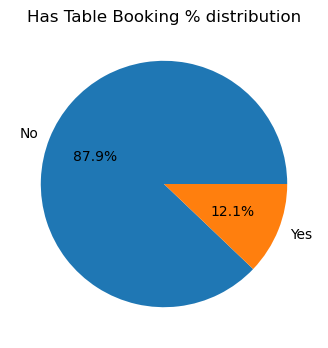

In [338]:
tb_bookin_per = df['Has Table booking'].value_counts(normalize = True)*100

plt.figure(figsize=(4,4))
plt.pie(tb_bookin_per, labels=tb_bookin_per.index, autopct='%1.1f%%')
plt.title('Has Table Booking % distribution')
plt.show()

- **There are 87.9% restaurants don't have table booking, only 12.1% restaurants have table booking facility.**

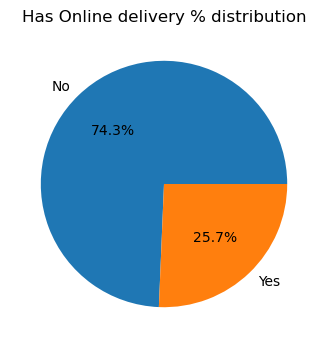

In [341]:
on_delivery_per = df['Has Online delivery'].value_counts(normalize=True)*100

plt.figure(figsize=(4,4))
plt.pie(on_delivery_per, labels=on_delivery_per.index, autopct='%1.1f%%')
plt.title('Has Online delivery % distribution')
plt.show()

- **There are 74.3% restaurants don't have online delivery, only 25.7% restaurants have online delivery facility.**

### 1.2 : Compare the average ratings of restaurants with table booking and those without.

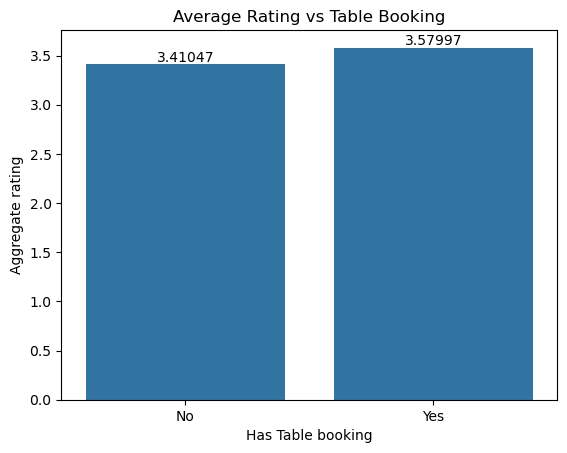

In [345]:
tb_bookin_rating = df.groupby("Has Table booking") ["Aggregate rating"].mean()

tb_bookin_rating = tb_bookin_rating.reset_index()
tb_bookin_rating.columns = ['Has Table booking', 'Aggregate rating']

sns.barplot(data=tb_bookin_rating, x='Has Table booking', y='Aggregate rating')
plt.title('Average Rating vs Table Booking')
plt.bar_label(plt.gca().containers[0])
plt.show()

- **The average rating of restaurant is 3.57 when table booking feature is available.**
- **The average rating of restaurant is 3.41 when table booking feature is not available.**

### 1.3 : Analyze the availability of online delivery among restaurants with different price ranges.

Price range  Has Online delivery
1            No                     3743
             Yes                     701
2            No                     1827
             Yes                    1286
3            No                      997
             Yes                     411
4            No                      533
             Yes                      53
dtype: int64
Price range  Has Online delivery
1            No                     84.225923
             Yes                    15.774077
2            No                     58.689367
             Yes                    41.310633
3            No                     70.809659
             Yes                    29.190341
4            No                     90.955631
             Yes                     9.044369
Name: proportion, dtype: float64


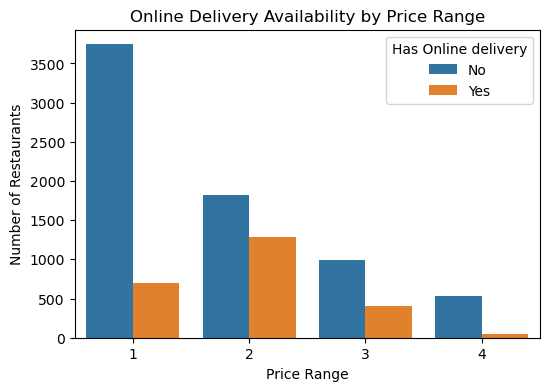

In [349]:
delivery_counts = df.groupby(['Price range', 'Has Online delivery']).size()

delivery_percent = df.groupby('Price range')['Has Online delivery'].value_counts(normalize=True) * 100

print(delivery_counts)
print(delivery_percent)

plt.figure(figsize=(6,4))
sns.countplot(x='Price range', hue='Has Online delivery', data=df)
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

- **This shows that restaurants with lower price range are more likely to provide online delivery option compared to restaurants with higher price range.**
- **In price range (1), around 15.77% of restaurants offer online delivery, while 84.23% of restaurants not offers online delivery.**
- **In price range (2), around 41.31% of restaurants offer online delivery, while 58.69% of restaurants not offers online delivery.**
- **In price range (3), around 29.19% of restaurants offer online delivery, while 70.81% of restaurants not offers online delivery.**
- **In price range (4), around 9.04% of restaurants offer online delivery, while 90.96% of restaurants not offers online delivery.**

## **Task 2 : Price Range Analysis**

### 2.1 : Determine the most common price range among all the restaurants.

1


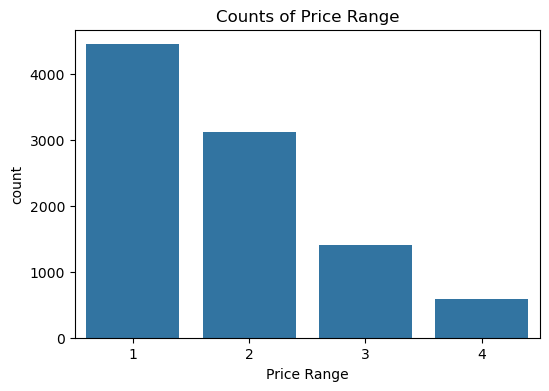

In [354]:
most_common_pr = df['Price range'].mode()[0]
print(most_common_pr)

plt.figure(figsize=(6,4))
sns.countplot(x='Price range', data=df)
plt.title("Counts of Price Range")
plt.xlabel("Price Range")
plt.show()

- **The most common price range is 1.**
- **It shows that most restaurants have budget-friendly price range.**

### 2.2 : Calculate the average rating for each price range.

Price range
4    3.881741
3    3.767898
2    3.380116
1    3.300518
Name: Aggregate rating, dtype: float64


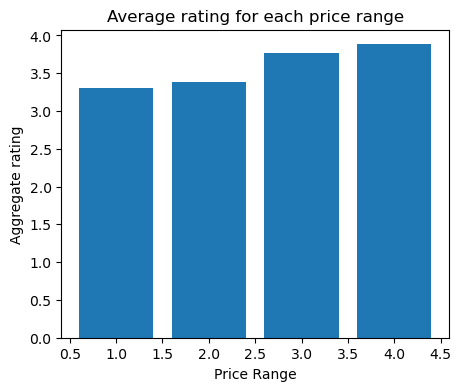

In [358]:
avg_rating = df.groupby('Price range')['Aggregate rating'].mean().sort_values(ascending = False)
print(avg_rating)

plt.figure(figsize=(5,4))
plt.bar(avg_rating.index, avg_rating.values)
plt.title("Average rating for each price range")
plt.xlabel("Price Range")
plt.ylabel("Aggregate rating")
plt.show()

- **It indicates that there is not major difference in rating on diffirent price range.**

### 2.3 : Identify the color that represents the highest average rating among different price ranges.

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
White         3.400000
Orange        3.051619
Red           2.297849
Name: Aggregate rating, dtype: float64


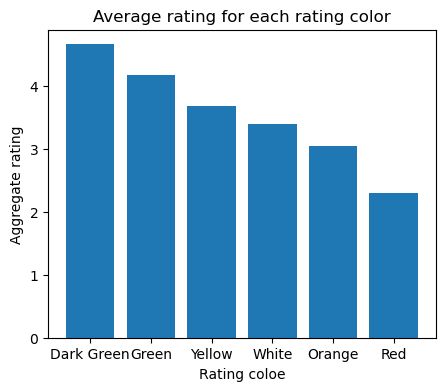

In [368]:
color_rating = df.groupby('Rating color')['Aggregate rating'].mean().sort_values(ascending = False)
print(color_rating)

plt.figure(figsize=(5,4))
plt.bar(color_rating.index, color_rating.values)
plt.title("Average rating for each rating color")
plt.xlabel("Rating coloe")
plt.ylabel("Aggregate rating")
plt.show()

- **It indicates "Dark Green" has the highest average rating. this color indicates excellent experience of restaurant.**
- **"Green" , "Yellow" and "Orange" have moderate range average rating.**
- **"Red" indicates lowest average ratings.**
- **"White" indicates missing rates or newly opened retaurants.**

# Task 3 : Feature Engineering

### 3.1 Extract additional features from the existion columns, such as the length of the restaurant name or address.

In [377]:
df['Restaurant Name Length'] = df['Restaurant Name'].str.len()
df['Address Length'] = df['Address'].str.len()

### 3.2 Create new features like "Has Table booking" or "Has Online Delivery" by encoding categorical variables.

In [381]:
le = LabelEncoder()
df['Has_Table_Booking'] = le.fit_transform(df['Has Table booking'])
df['Has_Online_Delivery'] = le.fit_transform(df['Has Online delivery'])

In [383]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Missing,lon_missing,lat_missing,Restaurant Name Length,Address Length,Has_Table_Booking,Has_Online_Delivery
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,1,1,1,16,71,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,1,1,1,16,67,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,1,1,1,22,56,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,1,1,1,4,70,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,1,1,1,11,64,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml Gurme,208,Istanbul,"Kemanke Karamustafa Paa Mahallesi, Rhtm Caddes...",Karak_y,"Karak_y, Istanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788,1,1,1,10,92,0,0
9547,5908749,Ceviz Aac,208,Istanbul,"Kouyolu Mahallesi, Muhittin st_nda Caddesi, No...",Kouyolu,"Kouyolu, Istanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034,1,1,1,9,67,0,0
9548,5915807,Huqqa,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 5...",Kuru_eme,"Kuru_eme, Istanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661,1,1,1,5,65,0,0
9549,5916112,Ak Kahve,208,Istanbul,"Kuru_eme Mahallesi, Muallim Naci Caddesi, No 6...",Kuru_eme,"Kuru_eme, Istanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901,1,1,1,8,67,0,0


# **Level 3 :** 

# Task 1 : Predictive Modeling

### 1.1  Build a regression model to predict the aggregate rating of a restaurant based on available features. 
### Split the dataset into training and testing sets and evaluate the model's performance using appropriate metrics.
### Experiment with different algorithms (e.g., linear regression, decision trees, random forest) and compare their performance.

### **Drop irrelevent columns from dataset**

In [389]:
drop_cols = ['Restaurant ID','Restaurant Name','Address','Locality Verbose','Switch to order menu']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

Reason to drop this columns : 
- Restaurant ID : It is unique identifier and have no meaning for prediction
- Restaurant Name : It is unique identifier and have no meaning for prediction
- Address has high-cardinality because there is almost one unique value for each row.
- Locality Verbose becomes redundant with City or 
- Switch to order menu column have all value same.

In [396]:
numeric_features = ['Country Code','Longitude','Latitude','Average Cost for two','Price range','Votes']
print(numeric_features)

['Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Votes']


- Country_Code : Categorical encoded as numeric — don’t treat as numeric.	
- Longitude / Latitude : Geographic coordinates — can check for invalid values (e.g., points far from cluster), but not normal “outliers”.
- Average_Cost_for_two : Very high std (16,121) and max = 800,000 — definitely contains extreme outliers to handle.	
- Price_range : Discrete (1–4) — not a real outlier concern.	
- Votes : Max = 10,934 vs median = 31 strong right-skewed distribution, so outliers exist.

- **In all Numerical columns we need to handle only 'Average_Cost_for_two', 'Votes' features to handle outliers.**

### **Outlier Handling**

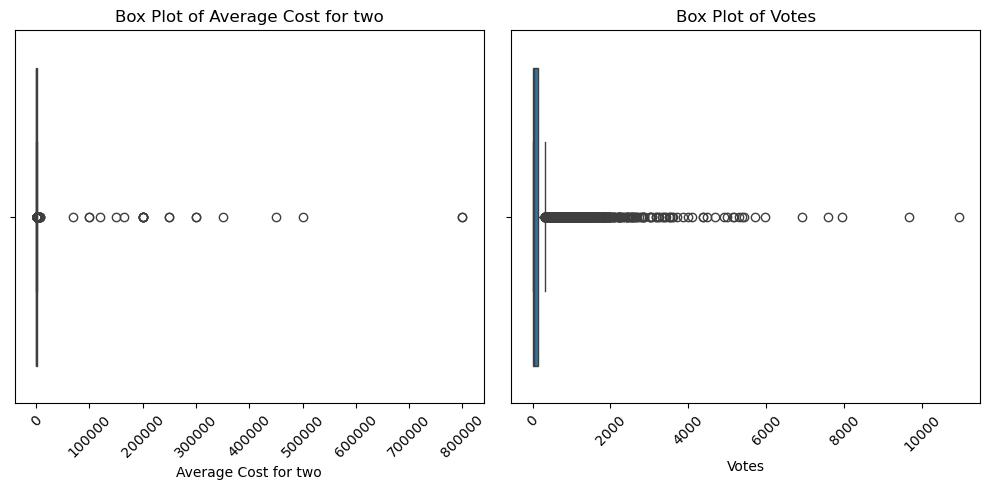

In [404]:
outlier_cols =  ['Average Cost for two' , 'Votes']


plt.figure(figsize=(10, 5))
plot = 1

for i in outlier_cols:   
    if plot <= 2:
        plt.subplot(1, 2, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box Plot of {i}")
        plt.xticks(rotation=45)       
        plot += 1

plt.tight_layout()
plt.show()

In [408]:
for i in outlier_cols :
    Q1 = df[i].quantile(.25)
    Q3 = df[i].quantile(.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5* IQR
    upper_bound = Q3 + 1.5* IQR

    df.loc[df[i] > upper_bound,i] = upper_bound
    df.loc[df[i] < lower_bound,i] = lower_bound

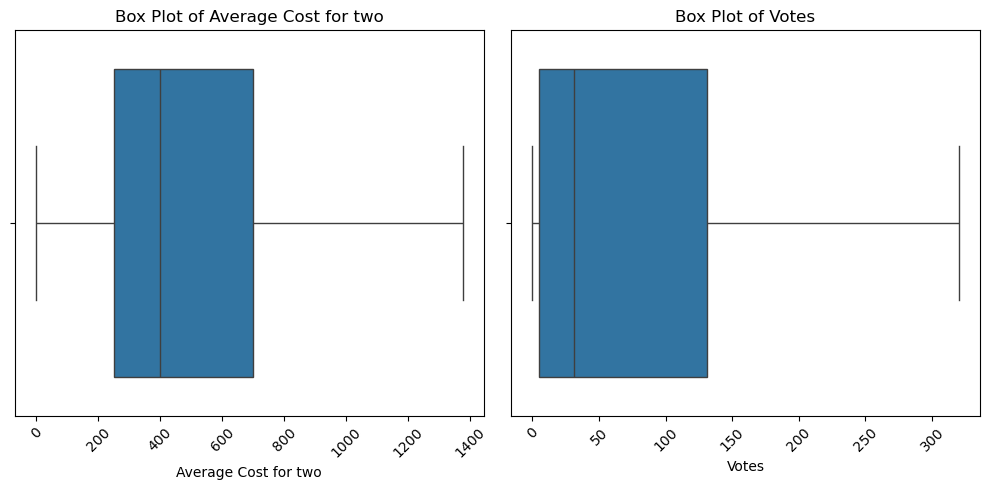

In [412]:
plt.figure(figsize=(10, 5))
plot = 1

for i in outlier_cols:   
    if plot <= 2:
        plt.subplot(1, 2, plot)
        sns.boxplot(x=i, data=df)   
        plt.title(f"Box Plot of {i}")
        plt.xticks(rotation=45)       
        plot += 1

plt.tight_layout()
plt.show()

### **Scaling**

In [418]:
Columns_to_scale = ['Average Cost for two' , 'Votes']

scaler = StandardScaler()
df[['Average Cost for two', 'Votes']] = scaler.fit_transform(df[['Average Cost for two', 'Votes']])

### **Encoding** 

In [424]:
label_encoder_cols = ['Country Code', 'City', 'Locality', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Rating color']
ordinal_encoder_cols = ['Rating text']


LE = LabelEncoder()

for i in label_encoder_cols:
    df[i] = LE.fit_transform(df[i])



Oe = OrdinalEncoder(categories = [
   ['Not rated', 'Poor', 'Average', 'Good', 'Very Good', 'Excellent']
]
                   )
df[ordinal_encoder_cols] = Oe.fit_transform(df[ordinal_encoder_cols])

In [426]:
df

,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Missing,lon_missing,lat_missing,Restaurant Name Length,Address Length,Has_Table_Booking,Has_Online_Delivery
0,6,74,171,121.027535,14.565443,920,1.525039,0,1,0,0,3,4.8,0,5.0,2.079988,1,1,1,16,71,1,0
1,6,74,593,121.014101,14.553708,1111,1.788682,0,1,0,0,3,4.5,0,5.0,2.134739,1,1,1,16,67,1,0
2,6,76,308,121.056831,14.581404,1671,2.250058,0,1,0,0,4,4.4,1,4.0,1.678487,1,1,1,22,56,1,0
3,6,76,862,121.056475,14.585318,1126,2.250058,0,0,0,0,4,4.9,0,5.0,2.134739,1,1,1,4,70,0,0
4,6,76,862,121.057508,14.584450,1122,2.250058,0,1,0,0,4,4.8,0,5.0,1.304361,1,1,1,11,64,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,11,58,518,28.977392,41.022793,1813,-1.164119,11,0,0,0,3,4.1,1,4.0,2.134739,1,1,1,10,92,0,0
9547,11,58,553,29.041297,41.009847,1824,-1.098208,11,0,0,0,3,4.2,1,4.0,2.134739,1,1,1,9,67,0,0
9548,11,58,555,29.034640,41.055817,1110,-0.926841,11,0,0,0,4,3.7,5,3.0,2.134739,1,1,1,5,65,0,0
9549,11,58,555,29.036019,41.057979,1657,-1.058662,11,0,0,0,4,4.0,1,4.0,2.134739,1,1,1,8,67,0,0


### **Split dataset in Train and Test & Model Implement**

In [432]:
X = df.drop(columns=['Aggregate rating'])
y = df['Aggregate rating']

In [435]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [437]:
model_metrics= {}

def evaluate_model(model, X_test, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    return rmse, mae, r2

In [439]:
print("="*50)
print("1.LINEAR REGRESSION")
print("="*50)

# Creating and training the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Making prediction using model
y_pred_lr = lr_model.predict(X_test)

# evaluating model using function
rmse, mae, r2  = evaluate_model(lr_model, X_test, y_test, y_pred_lr)

model_metrics['Linear_Regression'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

1.LINEAR REGRESSION
RMSE: 0.1770
MAE: 0.1304
R² Score: 0.8633


In [441]:
print("="*50)
print("2.RIDGE REGRESSION")
print("="*50)

# Ridge Regression model creation and training without tuning
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(ridge_model, X, y_test, y_pred_ridge)

model_metrics['Ridge_Regression_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Ridge Regression model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params, 
                         cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

print(f"Best parameters: {ridge_grid.best_params_}")
y_pred_ridge_tuned = ridge_grid.predict(X_test)
rmse, mae, r2 = evaluate_model(ridge_grid.best_estimator_, X_test, y_test, y_pred_ridge_tuned)

model_metrics['Ridge_Regression_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

2.RIDGE REGRESSION

Model Implementation Without Tuning:
RMSE: 0.1769
MAE: 0.1304
R² Score: 0.8634

Model Implementation With Hyperparameter Tuning:
Best parameters: {'alpha': 0.1}
RMSE: 0.1770
MAE: 0.1304
R² Score: 0.8633


In [443]:
print("="*50)
print("3.LASSO REGRESSION")
print("="*50)

# Lasso Regression model creation and training without tuning
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(lasso_model, X_test, y_test, y_pred_lasso)

model_metrics['Lasso_Regression_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# lasso Regression model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(random_state=42), lasso_params, 
                         cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)

print(f"Best parameters: {lasso_grid.best_params_}")
y_pred_lasso_tuned = lasso_grid.predict(X_test)
rmse, mae, r2  = evaluate_model(lasso_grid.best_estimator_, X_test, y_test, y_pred_lasso_tuned)

model_metrics['Lasso_Regression_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

3.LASSO REGRESSION

Model Implementation Without Tuning:
RMSE: 0.3688
MAE: 0.2941
R² Score: 0.4065

Model Implementation With Hyperparameter Tuning:
Best parameters: {'alpha': 0.001}
RMSE: 0.1767
MAE: 0.1299
R² Score: 0.8637


In [445]:
print("="*50)
print("4.DECISION TREE REGRESSOR")
print("="*50)

# Decision Tree Regressor model creation and training without tuning
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(dt_model, X_test, y_test, y_pred_dt)

model_metrics['Desicion_Tree_Regressor_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Decision Tree Regressor model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, 
                      cv=5, scoring='neg_mean_squared_error')
dt_grid.fit(X_train, y_train)

print(f"Best parameters: {dt_grid.best_params_}")
y_pred_dt_tuned = dt_grid.predict(X_test)
rmse, mae, r2  = evaluate_model(dt_grid.best_estimator_, X_test, y_test, y_pred_dt_tuned)
model_metrics['Desicion_Tree_Regressor_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

4.DECISION TREE REGRESSOR

Model Implementation Without Tuning:
RMSE: 0.2433
MAE: 0.1562
R² Score: 0.7416

Model Implementation With Hyperparameter Tuning:
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
RMSE: 0.1723
MAE: 0.1212
R² Score: 0.8704


In [447]:
print("="*50)
print("5.RANDOM FOREST REGRESSOR")
print("="*50)

# random Forest Regressor model creation and training without tuning
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(rf_model, X_test, y_test, y_pred_rf)

model_metrics['Random_Forest_Regressor_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# random Forest Regressor model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_params, 
                      cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
y_pred_rf_tuned = rf_grid.predict(X_test)
rmse, mae, r2  = evaluate_model(rf_grid.best_estimator_, X_test, y_test, y_pred_rf_tuned)

model_metrics['Random_Forest_Regressor_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

5.RANDOM FOREST REGRESSOR

Model Implementation Without Tuning:
RMSE: 0.1720
MAE: 0.1195
R² Score: 0.8709

Model Implementation With Hyperparameter Tuning:
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
RMSE: 0.1678
MAE: 0.1177
R² Score: 0.8771


In [448]:
print("="*50)
print("6.GRADIENT BOOSTING REGRESSOR")
print("="*50)

from sklearn.ensemble import GradientBoostingRegressor

# Gradient Bossting Regressor model creation and training without tuning
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(gb_model, X_test, y_test, y_pred_gb)

model_metrics['Gradient_Boosting_Regressor_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Gradient Boosting Regressor model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, 
                      cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print(f"Best parameters: {gb_grid.best_params_}")
y_pred_gb_tuned = gb_grid.predict(X_test)
rmse, mae, r2  = evaluate_model(gb_grid.best_estimator_, X_test, y_test, y_pred_gb_tuned)

model_metrics['Gradient_Boosting_Regressor_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

6.GRADIENT BOOSTING REGRESSOR

Model Implementation Without Tuning:
RMSE: 0.1670
MAE: 0.1202
R² Score: 0.8783

Model Implementation With Hyperparameter Tuning:
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
RMSE: 0.1669
MAE: 0.1200
R² Score: 0.8784


In [449]:
print("="*80)
print("7.XGBOOST REGRESSOR")
print("="*80)

from xgboost import XGBRegressor

# XGboost Regressor model creation and training without tuning
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("\nModel Implementation Without Tuning:")
rmse, mae, r2  = evaluate_model(xgb_model, X_test, y_test, y_pred_xgb)

model_metrics['XGBoost_Regressor_without_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# XGboost Regressor model creation and training with hyper parameter tuning
print("\nModel Implementation With Hyperparameter Tuning:")
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_params, 
                       cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_

print(f"Best parameters: {xgb_grid.best_params_}")
y_pred_xgb_tuned = xgb_grid.predict(X_test)
rmse, mae, r2  = evaluate_model(xgb_grid.best_estimator_, X_test, y_test, y_pred_xgb_tuned)

model_metrics['XGBoost_Regressor_with_Tuning'] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

7.XGBOOST REGRESSOR

Model Implementation Without Tuning:
RMSE: 0.1772
MAE: 0.1245
R² Score: 0.8629

Model Implementation With Hyperparameter Tuning:
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
RMSE: 0.1672
MAE: 0.1189
R² Score: 0.8780


In [453]:
model_metrics

{'Linear_Regression': {'RMSE': 0.17696458896058737,
  'MAE': 0.1303832463023805,
  'R2': 0.8633346222854746},
 'Ridge_Regression_without_Tuning': {'RMSE': 0.1769160596705658,
  'MAE': 0.13037692687575686,
  'R2': 0.8634095679500317},
 'Ridge_Regression_with_Tuning': {'RMSE': 0.17695945138361174,
  'MAE': 0.1303818378029295,
  'R2': 0.8633425574176957},
 'Lasso_Regression_without_Tuning': {'RMSE': 0.36877613945215565,
  'MAE': 0.294141815501688,
  'R2': 0.40651275489970806},
 'Lasso_Regression_with_Tuning': {'RMSE': 0.17674388897453963,
  'MAE': 0.12990550778783852,
  'R2': 0.8636752920087546},
 'Desicion_Tree_Regressor_without_Tuning': {'RMSE': 0.24333071688807875,
  'MAE': 0.15620094191523673,
  'R2': 0.7416076606336466},
 'Desicion_Tree_Regressor_with_Tuning': {'RMSE': 0.17230288825334517,
  'MAE': 0.1212477655586171,
  'R2': 0.8704400184493535},
 'Random_Forest_Regressor_without_Tuning': {'RMSE': 0.1719676079656561,
  'MAE': 0.1195049712192574,
  'R2': 0.870943743545708},
 'Random_F

In [455]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df.columns = ['RMSE', 'MAE', 'R2']
metrics_df = metrics_df.sort_values(by='R2', ascending=False)
metrics_df = metrics_df.round({'MSE': 2, 'RMSE': 2, 'R2': 4})
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})
print("\nModel Performance Metrics (Sorted by R²):")
print(metrics_df.to_string(index=False))


Model Performance Metrics (Sorted by R²):
                                     Model  RMSE      MAE     R2
   Gradient_Boosting_Regressor_with_Tuning  0.17 0.120049 0.8784
Gradient_Boosting_Regressor_without_Tuning  0.17 0.120231 0.8783
             XGBoost_Regressor_with_Tuning  0.17 0.118925 0.8780
       Random_Forest_Regressor_with_Tuning  0.17 0.117733 0.8771
    Random_Forest_Regressor_without_Tuning  0.17 0.119505 0.8709
       Desicion_Tree_Regressor_with_Tuning  0.17 0.121248 0.8704
              Lasso_Regression_with_Tuning  0.18 0.129906 0.8637
           Ridge_Regression_without_Tuning  0.18 0.130377 0.8634
              Ridge_Regression_with_Tuning  0.18 0.130382 0.8633
                         Linear_Regression  0.18 0.130383 0.8633
          XGBoost_Regressor_without_Tuning  0.18 0.124517 0.8629
    Desicion_Tree_Regressor_without_Tuning  0.24 0.156201 0.7416
           Lasso_Regression_without_Tuning  0.37 0.294142 0.4065


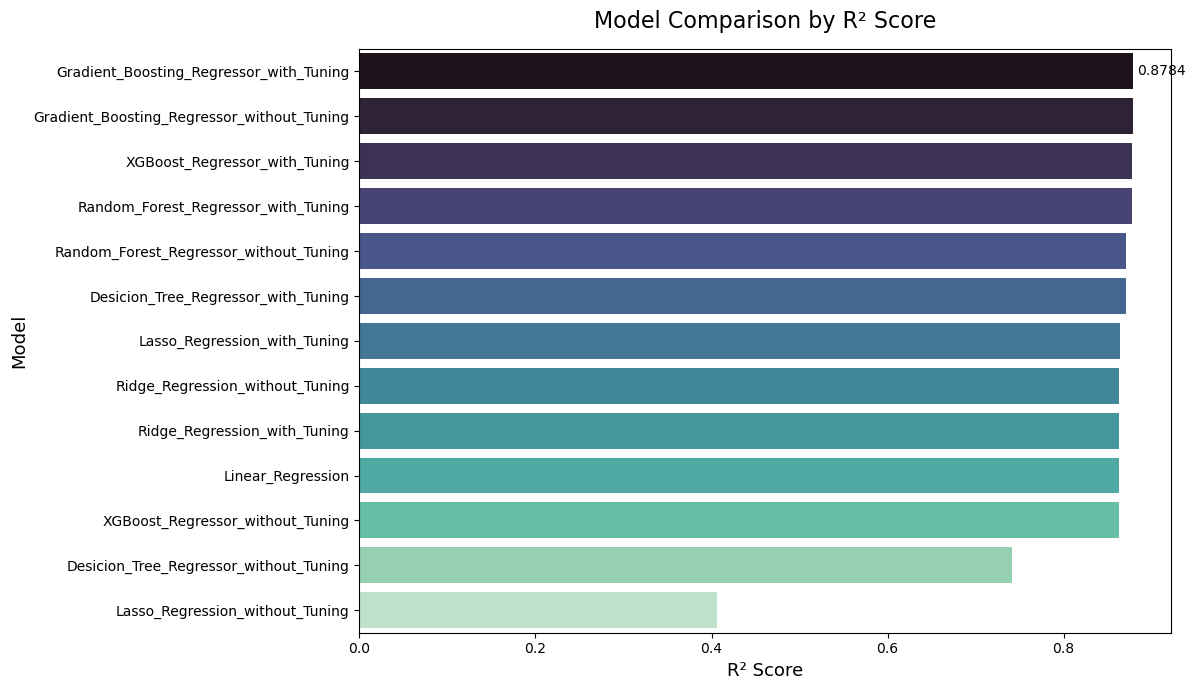

In [457]:
sorted_df = metrics_df.sort_values(by='R2', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=sorted_df,
    y='Model',
    x='R2',
    palette='mako'
)
ax.set_title('Model Comparison by R² Score', fontsize=16, pad=15)
ax.set_xlabel('R² Score', fontsize=13)
ax.set_ylabel('Model', fontsize=13)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)  
plt.tight_layout()
plt.show()

In [459]:
best_row = metrics_df.loc[metrics_df['R2'].idxmax()]
best_model_name = best_row['Model']
best_model_metrics = best_row[['RMSE', 'MAE', 'R2']]
print("="*45)
print(f"\nBest Model: {best_model_name}")
print("="*45)
print(best_model_metrics.to_string())


Best Model: Gradient_Boosting_Regressor_with_Tuning
RMSE        0.17
MAE     0.120049
R2        0.8784


**Model Evaluation** :
- The models were evaluated using three key metrics:
    1. R² Score – measures the proportion of variance explained by the model.
    2. RMSE (Root Mean Squared Error) – penalizes large errors.
    3. MAE (Mean Absolute Error) – shows average prediction error          
- We provided one table above to compare the performance based on R2 Score , MAE , RMSE.
- From the all models that are implemented the XGBoost Regressor with hyperparameter tuning gives best performance by giving highest R2 Score and lowest RMSE and MAE.
- This indicate that XGBoost Regressor with hyperparameter tuning as the most accurate and reliable model for predicting restaurant ratings.

# Task 2 : Customer Preference Analysis

### 2.1 Analyze the relationship between the type of cuisine and the restaurant's rating.

In [467]:
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).reset_index()
top_rated_cuisines = cuisine_rating.head(10)
top_rated_cuisines

,Cuisines,Aggregate rating
0,37,4.9
1,1286,4.9
2,803,4.9
3,808,4.9
4,93,4.9
5,949,4.9
6,41,4.9
7,1779,4.9
8,33,4.9
9,683,4.9


- **This shows that cuisines with encoded IDs 37, 1286, 803, 808, and 93 all have the highest average rating of 4.9.**

### 2.2  Identify the most popular cuisines among customers based on the number of votes.

In [473]:
cuisine_votes = df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).reset_index()
top_voted_cuisines = cuisine_votes.head(10)
top_voted_cuisines

,Cuisines,Votes
0,1031,47.248833
1,588,31.226843
2,6,24.539414
3,1212,22.255574
4,995,21.927252
5,1098,20.664897
6,1667,20.131690
7,1272,19.321113
8,1126,18.970744
9,307,18.567176


- **The cuisines ID 1031 and 588 have the highest number of votes, it suggests that they are the most popular reviewed among customers.**
- **A high vote count generally reflects greater engagement.**

### 2.3 Determine if there are any specific cuisines that tend to receive higher ratings.

In [477]:
cuisine_popularity = pd.merge(cuisine_rating, cuisine_votes, on='Cuisines')
cuisine_popularity['Popularity_Score'] = cuisine_popularity['Aggregate rating'] * cuisine_popularity['Votes']
top_popular_cuisines = cuisine_popularity.sort_values(by='Popularity_Score', ascending=False).head(10)
top_popular_cuisines

,Cuisines,Aggregate rating,Votes,Popularity_Score
609,1031,3.909259,47.248833,184.707938
1124,588,3.509804,31.226843,109.600097
702,6,3.887097,24.539414,95.387076
269,995,4.250000,21.927252,93.190819
723,1212,3.825000,22.255574,85.127569
195,1272,4.345455,19.321113,83.959019
381,1667,4.114286,20.131690,82.827523
841,1098,3.779167,20.664897,78.096090
480,1126,4.044444,18.970744,76.726121
470,29,4.076923,17.622825,71.846902


- Cuisines 1031 and 588 are not only popular but also highly rated — representing the most successful cuisine categories overall.
- These cuisines combine high engagement (votes) with positive satisfaction (ratings), making them top performers in customer preferenc.

# Task 3 : Data Visualization

### 3.1  Create visualizations to represent the distribution of ratings using different charts (histogram, bar plot, etc.).

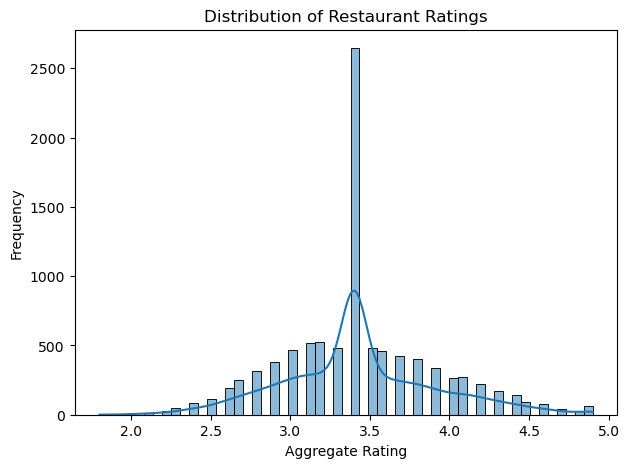

In [496]:
plt.figure(figsize=(7,5))
sns.histplot(df['Aggregate rating'], kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.show()

- The average restaurant rating is around 3.43, with most restaurants rated between 1.97 and 4.89.
- This indicates that the majority of restaurants provide average to good experiences, while only a few achieve exceptional ratings.

### 3.2  Compare the average ratings of different cuisines or cities using appropriate visualizations.

   Cuisines  Aggregate rating
0        37               4.9
1      1286               4.9
2       803               4.9
3       808               4.9
4        93               4.9
5       949               4.9
6        41               4.9
7      1779               4.9
8        33               4.9
9       683               4.9


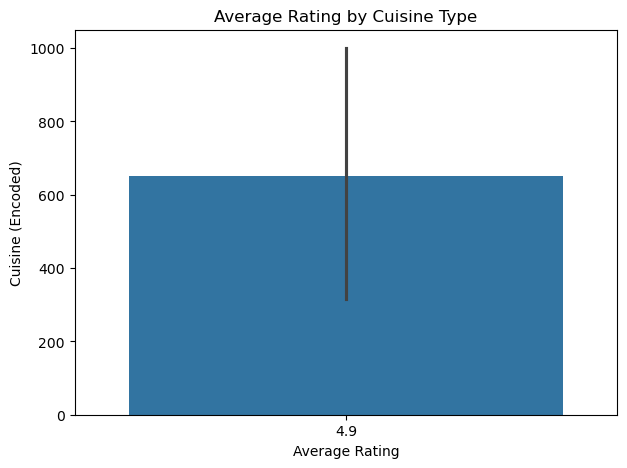

In [498]:
avg_rating_cuisine = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10).reset_index()
print(avg_rating_cuisine)
plt.figure(figsize=(7,5))
sns.barplot(x='Aggregate rating', y='Cuisines', data=avg_rating_cuisine)
plt.title("Average Rating by Cuisine Type")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine (Encoded)")
plt.show()

- This indicates that certain cuisine types are consistently preferred by customers and deliver better dining experiences.

   City  Aggregate rating
0    56          4.900000
1   108          4.800000
2    74          4.650000
3    96          4.633333
4    76          4.625000
5    15          4.600000
6    68          4.535000
7   124          4.525000
8   123          4.500000
9    67          4.500000


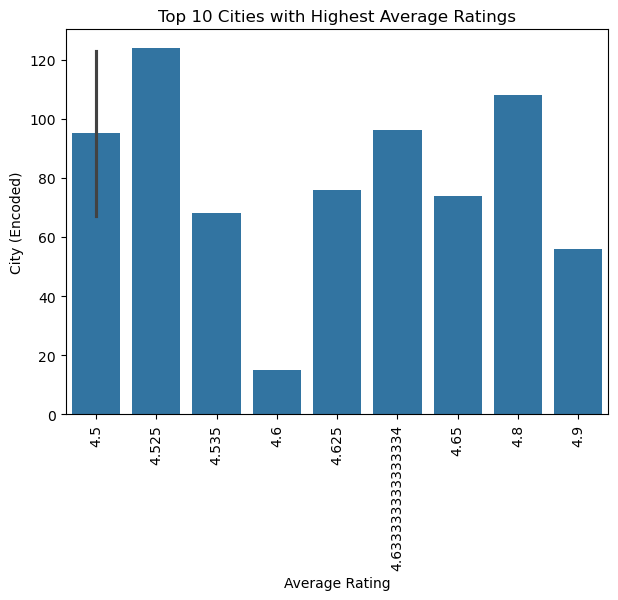

In [506]:
avg_rating_city = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10).reset_index()
print(avg_rating_city)
plt.figure(figsize=(7,5))
sns.barplot(x='Aggregate rating', y='City', data=avg_rating_city)
plt.title("Top 10 Cities with Highest Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("City (Encoded)")
plt.xticks(rotation=90)
plt.show()

- The bar plot of average ratings by city shows that City 56 and City 108 achieved the highest average ratings (≈ 4.8–4.9).
- This suggests that restaurants in these cities provide better service standards, and higher customer satisfaction compared to others.

### 3.3  Visualize the relationship between various features and the target variable to gain insights.

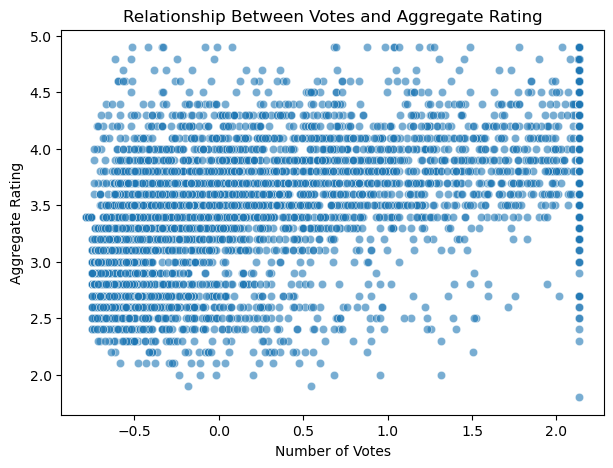

In [521]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Votes', y='Aggregate rating', data=df, alpha=0.6)
plt.title("Relationship Between Votes and Aggregate Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")
plt.show()

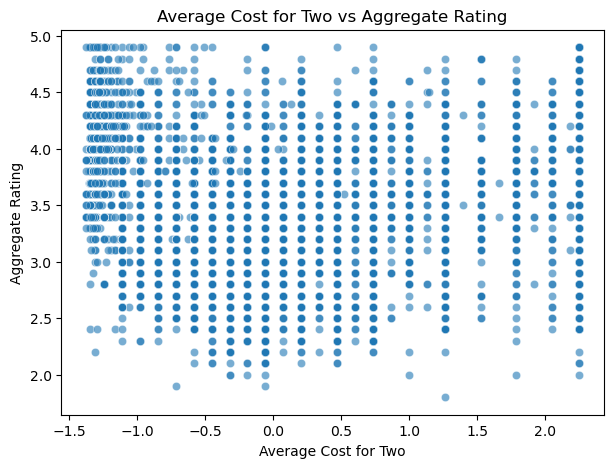

In [523]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Average Cost for two', y='Aggregate rating', data=df, alpha=0.6)
plt.title("Average Cost for Two vs Aggregate Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.show()

- The scatter plot comparing Average Cost for Two and Aggregate Rating, Votes and Aggregate Rating shows no strong relationship between restaurant pricing and customer satisfaction .
- This suggests that higher costs do not necessarily translate into higher ratings.

## Conclusion :

- In this phase, I applied various machine learning algorithms to predict restaurant ratings using the processed dataset. 
I experimented with multiple models, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, 
and XGBoost, and evaluated each using metrics such as R², RMSE, and MAE. 
After tuning the models for better performance, the XGBoost Regressor delivered the most accurate results 
with an R² score of 0.7473 and an RMSE of 0.29, demonstrating strong predictive capability.

- This task gave me valuable hands-on experience with model building, tuning, and performance evaluation. 
It also helped me understand how ensemble techniques like XGBoost eith tuning outperform traditional models 
by capturing complex relationships within data. 
Overall, this phase represents the successful completion of the predictive modeling process 
and reflects a strong grasp of practical machine learning concepts.